<div style="text-align: center; padding: 20px; font-family: Vazir;">
<h1 align="center" style="font-size: 28px; color:rgb(64, 244, 202); width: 100%;">⚜️━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━⚜️<br>تمرین 4<br>⚜️━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━⚜️</h1>
<h2 style="color:rgb(90, 255, 184); font-size: 20px;">Comparing BART and GPT-2 for Text-to-SQL</h2>
<p align="center" style="color: #666; font-size: 16px;">زهرا فیض اله زاده</p>
<p align="center" style="color: #666; font-size: 16px; margin-bottom: 30px;">zahra.feizolahzadeh@gmail.com</p>

<div dir="rtl" style="border: 2px dashed rgb(90, 255, 184); border-radius: 8px; padding: 20px; margin: 20px auto; max-width: 500px; text-align: right;">
<p style="color: rgb(64, 244, 202); font-size: 18px; margin-bottom: 15px;">📝 مشخصات دانشجو:</p>
<p style="color: #666; margin: 5px;">نام و نام خانوادگی: {{نام_دانشجو}}</p>
<p style="color: #666; margin: 5px;">شماره دانشجویی: {{شماره_دانشجویی}}</p>
<p style="color: #666; margin: 5px;">تاریخ ارسال: {{تاریخ_ارسال}}</p>
</div>
</div>

<div dir="rtl" style="text-align: justify; padding: 25px; background-color:#6B7280;  border-radius: 12px; border: 2px solid rgb(2, 34, 22); font-family: Vazir;">
<div style="line-height: 2.0; font-size: 17px; color: black; font-family: Vazir;">
<div style="padding-right:40px">
</div>
<br>
<div style="padding-right:100px">
📋 <b>ساختار تمرین:</b>
<br>
<li><b>سوال اول - <span dir="ltr">Text-to-SQL with BART and GPT-2</span> (50)</b></li>
<ul>
<li>بخش اول: بارگذاری و پیش‌پردازش داده‌های Text-to-SQL</li>
<li>بخش دوم: آموزش مدل Encoder–Decoder (BART)</li>
<li>بخش سوم: آموزش مدل Decoder-only (GPT-2)</li>
<li>بخش چهارم: مقایسه و تحلیل نهایی</li>

</ul>

</div>
</div>
<div dir='rtl' style="line-height: 1.8; font-family: Vazir; font-size: 16px; margin-top: 20px; background-color: #e8eaf6; padding: 15px; border-radius: 8px; color:black">
💡 <b>نکات مهم:</b>
<br>
<li>	مسئله Text-to-SQL حساسیت بسیار بالایی به جزئیات دارد.</li>
کوچک‌ترین اختلاف در ساختار SQL، ترتیب کلیدواژه‌ها یا حتی فاصله‌ها می‌تواند باعث نامعتبر شدن خروجی شود. بنابراین هنگام ارزیابی، به‌ویژه در معیار Normalized EM، باید دقت زیادی به اصلاح فاصله‌ها، حذف سمیکالن اضافه، و یکسان‌سازی case کلمات داشته باشید تا مقایسه‌ای منصفانه انجام شود.
<li>	معماری‌های Encoder–Decoder و Decoder-only رفتارهای متفاوتی در تولید SQL دارند.</li>
ساخت صحیح ورودی‌ها (Prefix)، نحوه قرار دادن question و schema در متن، ترتیب tokenها،          padding مناسب و mask کردن بخش‌های غیرهدف، همگی نقش اساسی در عملکرد این مدل‌ها دارند. دقت کنید که GPT-2 باید تمام اطلاعات را در قالب یک توالی یکپارچه دریافت کند، درحالی‌که BART ورودی را رمزگذاری و سپس خروجی SQL را مستقل تولید می‌کند.
<li>	برای مقایسه مدل‌ها، آموزش حداقلی اما واقعی لازم است.</li>
باید حداقل یک ایپاک کامل روی حداقل ۲۰۰۰ نمونه از داده‌های آموزش اجرا شود تا مدل به‌طور معنی‌دار الگوهای اولیه Text-to-SQL را یاد بگیرد و ارزیابی‌ها قابل اعتماد باشند. لازم نیست آموزش طولانی انجام دهید، اما اجرای همین مقدار حداقلی برای تحلیل و مقایسه معماری‌ها ضروری است.
</div>
</div>

In [1]:
!pip install -U datasets evaluate transformers==4.49.0 sentencepiece huggingface_hub fsspec


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 74.7 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 512.3/512.3 kB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 78.1 MB/s eta 0:00:00:00:01
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.1
    Uninstalling tokenizers-0.22.1:
      Successfully uninstalled tokenizers-0.22.1
  Attempting uninstall: transformers
    Found existing installation: transformers 4.57.1
    Uninstalling transformers-4.57.1:
      Successfully uninstalled transformers-4.57.1
  Attempting uninstall: datasets
    Found existing installation: datasets 4.4.1
    Uninstalling datasets-4.4.1:
      Successfully uninstalled datasets-4.4.1


In [2]:
TRAIN_SIZE = 2000
DEV_SIZE = 300
TEST_SIZE = 300



In [7]:

import pandas as pd
import numpy as np
from datasets import load_dataset
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')
from transformers import GPT2LMHeadModel, GPT2Tokenizer

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    BartForConditionalGeneration,
    BartTokenizer,
    AdamW,
    get_linear_schedule_with_warmup
)
from tqdm import tqdm
import time
import re
import sqlparse

import matplotlib.pyplot as plt
import seaborn as sns


# <div style="text-align: center; direction: rtl; font-family: Vazir;"><h1 align="center" style="font-size: 24px; padding: 20px;">⚜️━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━⚜️<br>سوال دوم: تحلیل و مقایسه معماری‌های Encoder–Decoder و Decoder-Only در تسک Text-to-SQL <br>⚜️━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━⚜️</h1></div>


<p dir="rtl" style="text-align: right; padding:30px; background-color:rgb(12, 12, 12); border-radius: 12px; color: white; font-family: Vazir;">
در این بخش از تمرین با مسئله Text-to-SQL آشنا می‌شوید؛ وظیفه‌ای که در آن مدل باید پرسش‌های زبان طبیعی را به کوئری SQL معتبر تبدیل کند. هدف تمرین، مقایسه عملی دو معماری مهم ترنسفورمری است: Encoder–Decoder‌ (مانند BART) و Decoder-only‌ (مانند GPT-2). پس از آماده‌سازی داده‌ها، ابتدا مدل BART و سپس مدل GPT-2 را برای این تسک آموزش می‌دهید و در نهایت عملکرد دو مدل را از نظر دقت، رفتار تولیدی و انواع خطاها تحلیل و مقایسه خواهید کرد.
</p>




## <div style="text-align: center; direction: rtl; font-family: Vazir;">بخش اول: مجموعه‌داده و پیش‌پردازش(10 نمره)</div>


<div dir="rtl" style="text-align: right; padding:10px; background-color:#6B7280;  border-radius: 12px; border: 2px solid rgb(2, 34, 22); font-family: Vazir;">
داده‌های Gretel Synthetic Text-to-SQL را از HuggingFace بارگذاری کرده و فایل‌های train/test را دریافت کنید. ساختار دیتاست را بررسی کرده، یک نمونه نمایش دهید و نقش ستون‌های اصلی از جمله question، schema و query را توضیح دهید. سپس داده‌ها را با استفاده از train_test_split به بخش‌های train و dev تقسیم کنید و ستون‌ها را به اسامی استاندارد (question، schema، query) تغییر دهید. برای کاهش زمان آموزش، روی هر بخش محدودیت اندازه تعیین کنید. در پایان، تحلیل کوتاهی از ماهیت پرسش‌ها، ساختار schemaها و چالش‌هایی که برای مدل ایجاد می‌کنند ارائه دهید.
</div>


<p dir='rtl' style="line-height: 2.0; text-align: right; font-family: Vazir; font-size: 16px; margin-top: 20px; color: white; background-color:rgb(0, 40, 30); padding: 30px; border-radius: 8px;">
🎯 <b>خروجی مورد انتظار:</b><br>
در پایان این بخش انتظار می‌رود دانشجو یک دیتافریم کاملا آماده برای مراحل بعدی در اختیار داشته باشد. خروجی مطلوب شامل بارگذاری صحیح فایل‌های train و test، نمایش ساختار کلی داده‌ها، تقسیم درست داده‌ها به بخش‌های train و dev، تغییر نام ستون‌ها به قالب استاندارد، و اعمال زیرنمونه‌گیری برای محدود کردن حجم داده‌ها است. علاوه بر این، باید یک نمونه واقعی از داده‌ها همراه با توضیح مختصر درباره ماهیت سؤال، ساختار schema و نمونه SQL نمایش داده شود تا مشخص شود داده‌ها به‌درستی پردازش شده و برای ورود به مراحل آموزش مدل آماده هستند.

</p>

In [8]:
dataset = load_dataset("gretelai/synthetic_text_to_sql")


README.md: 0.00B [00:00, ?B/s]

synthetic_text_to_sql_train.snappy.parqu(…):   0%|          | 0.00/32.4M [00:00<?, ?B/s]

synthetic_text_to_sql_test.snappy.parque(…):   0%|          | 0.00/1.90M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/100000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5851 [00:00<?, ? examples/s]

In [9]:
dataset

DatasetDict({
    train: Dataset({
        features: ['id', 'domain', 'domain_description', 'sql_complexity', 'sql_complexity_description', 'sql_task_type', 'sql_task_type_description', 'sql_prompt', 'sql_context', 'sql', 'sql_explanation'],
        num_rows: 100000
    })
    test: Dataset({
        features: ['id', 'domain', 'domain_description', 'sql_complexity', 'sql_complexity_description', 'sql_task_type', 'sql_task_type_description', 'sql_prompt', 'sql_context', 'sql', 'sql_explanation'],
        num_rows: 5851
    })
})

In [10]:
dataset["train"]

Dataset({
    features: ['id', 'domain', 'domain_description', 'sql_complexity', 'sql_complexity_description', 'sql_task_type', 'sql_task_type_description', 'sql_prompt', 'sql_context', 'sql', 'sql_explanation'],
    num_rows: 100000
})

In [14]:
train_df = pd.DataFrame(dataset['train'])
test_df = pd.DataFrame(dataset['test'])

print(f"Train shape: {train_df.shape}, Test shape: {test_df.shape}")
print(train_df.head())
print(train_df['sql_prompt'][0])
print(train_df['sql'][0])



Train shape: (100000, 11), Test shape: (5851, 11)
     id              domain  \
0  5097            forestry   
1  5098    defense industry   
2  5099      marine biology   
3  5100  financial services   
4  5101              energy   

                                  domain_description    sql_complexity  \
0  Comprehensive data on sustainable forest manag...       single join   
1  Defense contract data, military equipment main...       aggregation   
2  Comprehensive data on marine species, oceanogr...         basic SQL   
3  Detailed financial data including investment s...       aggregation   
4  Energy market data covering renewable energy s...  window functions   

                          sql_complexity_description            sql_task_type  \
0        only one join (specify inner, outer, cross)  analytics and reporting   
1  aggregation functions (COUNT, SUM, AVG, MIN, M...  analytics and reporting   
2           basic SQL with a simple select statement  analytics and reporti

In [15]:
print(f"\n Columns in the dataset: {train_df.columns.tolist()}")
print(f"Number of training samples: {len(train_df)}")
print(f"Number of testing samples: {len(test_df)}")


 Columns in the dataset: ['id', 'domain', 'domain_description', 'sql_complexity', 'sql_complexity_description', 'sql_task_type', 'sql_task_type_description', 'sql_prompt', 'sql_context', 'sql', 'sql_explanation']
Number of training samples: 100000
Number of testing samples: 5851


In [16]:

sample = train_df.iloc[0]
for col in sample.index:
    print(f"{col}:")
    print(f"  {sample[col]}")
    print("-"*80)

    train_df = train_df.rename(columns={'sql_prompt': 'question'})
    test_df = test_df.rename(columns={'sql_prompt': 'question'})



id:
  5097
--------------------------------------------------------------------------------
domain:
  forestry
--------------------------------------------------------------------------------
domain_description:
  Comprehensive data on sustainable forest management, timber production, wildlife habitat, and carbon sequestration in forestry.
--------------------------------------------------------------------------------
sql_complexity:
  single join
--------------------------------------------------------------------------------
sql_complexity_description:
  only one join (specify inner, outer, cross)
--------------------------------------------------------------------------------
sql_task_type:
  analytics and reporting
--------------------------------------------------------------------------------
sql_task_type_description:
  generating reports, dashboards, and analytical insights
--------------------------------------------------------------------------------
sql_prompt:
  What is t

In [17]:
if 'sql_context' in train_df.columns:
    train_df = train_df.rename(columns={'sql_context': 'schema'})
    test_df = test_df.rename(columns={'sql_context': 'schema'})

if 'sql' in train_df.columns:
    train_df = train_df.rename(columns={'sql': 'query'})
    test_df = test_df.rename(columns={'sql': 'query'})


In [18]:
required_columns = ['question', 'schema', 'query']
train_df = train_df[required_columns]
test_df = test_df[required_columns]


In [20]:
train_data, dev_data = train_test_split(
    train_df,
    test_size=0.15,
    random_state=42
)


In [21]:
train_data = train_data.head(TRAIN_SIZE).reset_index(drop=True)
dev_data = dev_data.head(DEV_SIZE).reset_index(drop=True)
test_data = test_df.head(TEST_SIZE).reset_index(drop=True)


In [22]:

print(f"Train size: {len(train_data)}")
print(f"Dev size: {len(dev_data)}")
print(f"Test size: {len(test_data)}")


print("\n:Sample from training data:")
print("="*80)
sample = train_data.iloc[5]
print(f" Question:\n{sample['question']}\n")
print(f" Schema:\n{sample['schema']}\n")
print(f" SQL Query:\n{sample['query']}\n")

train_data.to_csv("train_data.csv", index=False)
dev_data.to_csv("dev_data.csv", index=False)
test_data.to_csv("test_data.csv", index=False)


Train size: 2000
Dev size: 300
Test size: 300

:Sample from training data:
 Question:
What is the average carbon offset per building in the country of Germany, for buildings constructed between 2000 and 2010?

 Schema:
CREATE TABLE buildings (id INT, name VARCHAR(255), country VARCHAR(255), construction_date DATE, carbon_offset FLOAT);

 SQL Query:
SELECT AVG(carbon_offset) AS avg_carbon_offset FROM buildings WHERE country = 'Germany' AND YEAR(construction_date) BETWEEN 2000 AND 2010;



<div dir='rtl' style='background:#fffbe6; font-family: Vazir; border:1px dashed #f0ad4e; padding:12px; border-radius:8px; color:#111'>
✍️ <b>پاسخ تشریحی:</b><br><br>

<p style='line-height: 1.8; text-align: justify;'>
در این بخش، دیتاست <b>Gretel Synthetic Text-to-SQL</b> را از HuggingFace بارگذاری کردیم. این مجموعه‌داده شامل سه ستون اصلی است:
</p>

<ul style='line-height: 1.8;'>
<li><b>question:</b> پرسش به زبان طبیعی که کاربر می‌پرسد (مانند: "چند محصول در دسته الکترونیک داریم؟")</li>
<li><b>schema:</b> ساختار جداول پایگاه‌داده شامل نام جداول، ستون‌ها و روابط بین آن‌ها به صورت SQL CREATE TABLE</li>
<li><b>query:</b> کوئری SQL هدف که پاسخ صحیح به پرسش است</li>
</ul>

<p style='line-height: 1.8; text-align: justify;'>
<b>چالش‌های اصلی این تسک:</b>
</p>

<ol style='line-height: 1.8;'>
<li><b>پیچیدگی ساختاری:</b> مدل باید ساختار schema را درک کرده و نام جداول و ستون‌های صحیح را در SQL استفاده کند</li>
<li><b>دقت نحوی:</b> کوچکترین خطا در syntax (مانند فاصله، ویرگول یا کلیدواژه) باعث نامعتبر شدن کوئری می‌شود</li>
<li><b>استنباط معنایی:</b> مدل باید بفهمد که مفاهیم زبان طبیعی (مانند "چند تا") به کدام عملیات SQL (مانند COUNT) نگاشت می‌شوند</li>
<li><b>ترتیب منطقی:</b> استفاده صحیح از WHERE، JOIN، GROUP BY و ORDER BY نیازمند درک روابط بین جداول است</li>
</ol>

<p style='line-height: 1.8; text-align: justify;'>
برای آموزش کارآمد، داده‌ها را به ۲۰۰۰ نمونه train، ۳۰۰ نمونه dev و ۳۰۰ نمونه test محدود کردیم. این حجم برای مقایسه معماری‌های مختلف کافی است.
</p>
</div>

## <div style="text-align: center; direction: rtl; font-family: Vazir;">بخش دوم: آموزش مدل Encoder–Decoder (BART) (۱۵ نمره)</div>


<div dir="rtl" style="text-align: right; padding:10px; background-color:#6B7280;  border-radius: 12px; border: 2px solid rgb(2, 34, 22); font-family: Vazir;">
<p style="line-height: 1.8; text-align: right;">
در این بخش از تمرین، وارد مرحله‌ی پیاده‌سازی مدل BART می‌شویم. پیش از شروع، لازم است به‌صورت مختصر و دقیق توضیح دهید که مدل BART چیست و چگونه کار می‌کند؛ به‌ویژه این‌که چرا معماری Encoder–Decoder آن برای وظایفی مانند Text-to-SQL مناسب است. انتظار می‌رود دانشجو به ساختار دو‌بخشی BART، نحوهٔ پردازش ورودی در انکودر، و تولید خروجی در دیکودر اشاره کند و نشان دهد که این معماری برای نگاشت دنباله‌ای از کلمات (سؤال + schema) به دنباله‌ای دیگر (SQL) کاملاً مناسب است.
پس از توضیح مدل، باید قالب ورودی مناسبی طراحی کنید که در آن سؤال و schema به‌صورت یک رشتهٔ یکپارچه در اختیار مدل قرار گیرند. سپس یک Dataset اختصاصی برای BART بسازید که وظایفی مانند tokenize کردن ورودی، ساخت attention mask‌ها و آماده‌سازی SQL به عنوان خروجی هدف مدل را انجام دهد. مدل را حداقل یک ایپاک روی ۲۰۰۰ نمونه آموزش دهید و loss نهایی، زمان اجرا و هایپرپارامترهای اصلی را گزارش کنید.
در مرحلهٔ ارزیابی، باید عملکرد مدل را روی dev و test با دو معیار Raw Exact Match و Normalized Exact Match بسنجید.
از شما انتظار می‌رود که هر دو معیار را توضیح دهید:
Raw EM چگونه مقایسهٔ مستقیم دو رشته را انجام می‌دهد، چرا ممکن است برای SQL ناکافی باشد، و Normalized EM چگونه با حذف تفاوت‌های سطحی (مثل فاصله‌ها، علامت‌ها و بزرگی یا کوچکی حروف) مقایسه‌ای عادلانه‌تر ارائه می‌دهد.
در پایان، پنج نمونهٔ تصادفی از dev انتخاب کنید و پرسش، خروجی مدل، SQL طلایی و نوع خطاها را تحلیل کنید.
<div dir="rtl" style="text-align: right; padding:10px; background-color:#6B7280;  border-radius: 12px; border: 2px solid rgb(2, 34, 22); font-family: Vazir;">
نکته مهم:
برای پیاده‌سازی Raw EM می‌توانید از مقایسهٔ مستقیم رشته‌ها در پایتون استفاده کنید.
برای Normalized EM مجاز هستید از ابزارهایی مانند sqlparse برای فرمت‌بندی SQL و توابع سادهٔ پردازش متن جهت lowercase کردن و حذف فاصله‌های اضافی استفاده کنید، اما منطق مقایسه‌ی Normalized باید توسط خودتان نوشته شود.
</p>
</div>


<p dir='rtl' style="line-height: 2.0; text-align: right; font-family: Vazir; font-size: 16px; margin-top: 20px; color: white; background-color:rgb(0, 40, 30); padding: 30px; border-radius: 8px;">
🎯 <b>خروجی مورد انتظار:</b><br>
خروجی مورد انتظار این بخش، یک مدل BART آموزش‌دیده و ارزیابی‌شده است که بتواند از روی پرسش و ساختار پایگاه‌داده، کوئری SQL معتبر تولید کرده و معیارهای Raw EM و Normalized EM آن روی داده‌های dev و test گزارش شده باشد.
</p>

In [23]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model_name = "facebook/bart-base"
tokenizer = BartTokenizer.from_pretrained(model_name)
model = BartForConditionalGeneration.from_pretrained(model_name)
model = model.to(device)



vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/558M [00:00<?, ?B/s]

In [25]:
class BARTTextToSQLDataset(Dataset):
    def __init__(self, data, tokenizer, max_input_length=512, max_target_length=256):
        self.data = data
        self.tokenizer = tokenizer
        self.max_input_length = max_input_length
        self.max_target_length = max_target_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]

        input_text = f"question: {row['question']} schema: {row['schema']}"
        target_text = row['query']

        input_encoding = self.tokenizer(
            input_text,
            max_length=self.max_input_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        target_encoding = self.tokenizer(
            target_text,
            max_length=self.max_target_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        labels = target_encoding['input_ids'].squeeze()
        labels[labels == self.tokenizer.pad_token_id] = -100

        return {
            'input_ids': input_encoding['input_ids'].squeeze(),
            'attention_mask': input_encoding['attention_mask'].squeeze(),
            'labels': labels
        }

In [26]:
train_dataset = BARTTextToSQLDataset(train_data, tokenizer)
dev_dataset = BARTTextToSQLDataset(dev_data, tokenizer)
test_dataset = BARTTextToSQLDataset(test_data, tokenizer)


In [27]:
batch_size = 8
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
dev_loader = DataLoader(dev_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)



In [28]:
print(f"Number of training batches: {len(train_loader)}")

print(f"Number of dev batches: {len(dev_loader)}")
print(f"Number of test batches: {len(test_loader)}")


Number of training batches: 250
Number of dev batches: 38
Number of test batches: 38


In [30]:
epochs = 10
learning_rate = 3e-5
optimizer = AdamW(model.parameters(), lr=learning_rate)
total_steps = len(train_loader) * epochs
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)


In [31]:

print(f"   - Epochs: {epochs}")
print(f"   - Batch size: {batch_size}")
print(f"   - Learning rate: {learning_rate}")
print(f"   - Total training steps: {total_steps}")
print(f"   - Warmup steps: {int(0.1 * total_steps)}")


   - Epochs: 10
   - Batch size: 8
   - Learning rate: 3e-05
   - Total training steps: 2500
   - Warmup steps: 250


In [32]:
def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss = 0
    progress_bar = tqdm(loader, desc="Training")

    for batch in progress_bar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        total_loss += loss.item()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        progress_bar.set_postfix({'loss': loss.item()})

    return total_loss / len(loader)

In [33]:
start_time = time.time()

for epoch in range(epochs):
    print(f"\n Epoch {epoch + 1}/{epochs}")
    avg_loss = train_epoch(model, train_loader, optimizer, scheduler, device)
    print(f"   Average Loss: {avg_loss:.4f}")




 Epoch 1/10


Training: 100%|██████████| 250/250 [03:21<00:00,  1.24it/s, loss=1.39] 


   Average Loss: 2.2763

 Epoch 2/10


Training: 100%|██████████| 250/250 [03:32<00:00,  1.18it/s, loss=0.929]


   Average Loss: 1.0680

 Epoch 3/10


...

   Average Loss: 0.5499

 Epoch 6/10


Training: 100%|██████████| 250/250 [03:32<00:00,  1.18it/s, loss=0.563]


   Average Loss: 0.4831

 Epoch 7/10


Training:   6%|▌         | 15/250 [00:13<03:26,  1.14it/s, loss=0.262]


KeyboardInterrupt: 

In [35]:
training_time = time.time() - start_time

In [36]:
print(f"Time taken for training: {training_time:.2f} seconds ({training_time/60:.2f} minutes)")


Time taken for training: 1288.24 seconds (21.47 minutes)


In [37]:
model_save_path = "bart_text2sql_model"
model.save_pretrained(model_save_path)
tokenizer.save_pretrained(model_save_path)
print(f"\n💾 Model saved to {model_save_path}")


💾 Model saved to bart_text2sql_model


In [38]:
def normalize_sql(sql):
    try:
        sql = sql.strip()
        sql = sql.rstrip(';')
        sql = sql.lower()
        sql = sqlparse.format(sql, reindent=True, keyword_case='lower')
        sql = ' '.join(sql.split())
        return sql
    except:
        return sql.strip().lower()


In [39]:
def calculate_exact_match(predictions, references, normalized=False):
    if normalized:
        predictions = [normalize_sql(p) for p in predictions]
        references = [normalize_sql(r) for r in references]

    correct = sum([1 for p, r in zip(predictions, references) if p == r])
    return correct / len(predictions) * 100


In [40]:
def generate_sql(model, tokenizer, questions, schemas, device, max_length=256):
    model.eval()
    predictions = []

    with torch.no_grad():
        for question, schema in tqdm(zip(questions, schemas), total=len(questions), desc="Generating"):
            input_text = f"question: {question} schema: {schema}"

            inputs = tokenizer(
                input_text,
                max_length=512,
                truncation=True,
                return_tensors='pt'
            ).to(device)

            outputs = model.generate(
                **inputs,
                max_length=max_length,
                num_beams=4,
                early_stopping=True,
                no_repeat_ngram_size=2
            )

            sql = tokenizer.decode(outputs[0], skip_special_tokens=True)
            predictions.append(sql)

    return predictions



In [41]:
dev_predictions = generate_sql(
    model, tokenizer,
    dev_data['question'].tolist(),
    dev_data['schema'].tolist(),
    device
)

Generating: 100%|██████████| 300/300 [01:23<00:00,  3.59it/s]


In [42]:
dev_raw_em = calculate_exact_match(dev_predictions, dev_data['query'].tolist(), normalized=False)
dev_norm_em = calculate_exact_match(dev_predictions, dev_data['query'].tolist(), normalized=True)


In [43]:
print(f"   Raw Exact Match: {dev_raw_em:.2f}%")
print(f"   Normalized Exact Match: {dev_norm_em:.2f}%")


   Raw Exact Match: 14.33%
   Normalized Exact Match: 14.67%


In [44]:
test_predictions = generate_sql(
    model, tokenizer,
    test_data['question'].tolist(),
    test_data['schema'].tolist(),
    device
)


Generating: 100%|██████████| 300/300 [01:19<00:00,  3.77it/s]


In [45]:
test_raw_em = calculate_exact_match(test_predictions, test_data['query'].tolist(), normalized=False)
test_norm_em = calculate_exact_match(test_predictions, test_data['query'].tolist(), normalized=True)


In [46]:
print(f"   Raw Exact Match: {test_raw_em:.2f}%")
print(f"   Normalized Exact Match: {test_norm_em:.2f}%")


   Raw Exact Match: 16.67%
   Normalized Exact Match: 17.67%


In [47]:
sample_indices = np.random.choice(len(dev_data), 5, replace=False)

for i, idx in enumerate(sample_indices):
    print(f"\n Sample {i+1}:")
    print(f" Question: {dev_data.iloc[idx]['question']}")
    print(f"\n BART Prediction:\n{dev_predictions[idx]}")
    print(f"\n Gold SQL:\n{dev_data.iloc[idx]['query']}")

    pred_norm = normalize_sql(dev_predictions[idx])
    gold_norm = normalize_sql(dev_data.iloc[idx]['query'])

    if pred_norm == gold_norm:
        print(f"\n True Status: Correct")
    else:
        print(f"\n Wrong Status: Incorrect")
        print(f" Error Analysis: ", end="")

        if 'select' not in pred_norm:
            print("Invalid SQL structure")
        elif any(table in dev_data.iloc[idx]['schema'].lower() for table in ['from', 'join']) and 'from' not in pred_norm:
            print("Missing FROM clause")
        elif 'where' in gold_norm and 'where' not in pred_norm:
            print("Missing WHERE condition")
        elif pred_norm.count('select') > 1 and gold_norm.count('select') == 1:
            print("Incorrect use of subquery")
        else:
            print("General error in structure or naming")
    print("-"*100)



 Sample 1:
 Question: How many unique consumers have purchased sustainable materials, by region?

 BART Prediction:
SELECT region, COUNT(*) as unique_consumers FROM purchases GROUP BY region;

 Gold SQL:
SELECT region, COUNT(DISTINCT consumer_id) FROM ethical_fashion.purchases WHERE material IN ('cotton', 'polyester', 'wool') GROUP BY region;

 Wrong Status: Incorrect
 Error Analysis: Missing WHERE condition
----------------------------------------------------------------------------------------------------

 Sample 2:
 Question: Update the revenue data for a specific restaurant

 BART Prediction:
UPDATE revenue SET total_revenue = (SELECT revenue_date FROM revenue WHERE restaurant_id = 1;

 Gold SQL:
UPDATE revenue SET total_revenue = 5000.00 WHERE restaurant_id = 789 AND revenue_date = '2022-02-15';

 Wrong Status: Incorrect
 Error Analysis: General error in structure or naming
----------------------------------------------------------------------------------------------------

 Sam

In [48]:
bart_results = {
    'model': 'BART',
    'dev_raw_em': dev_raw_em,
    'dev_norm_em': dev_norm_em,
    'test_raw_em': test_raw_em,
    'test_norm_em': test_norm_em,
    'training_time': training_time,
    'predictions_dev': dev_predictions,
    'predictions_test': test_predictions
}



<div dir='rtl' style='background:#fffbe6; font-family: Vazir; border:1px dashed #f0ad4e; padding:12px; border-radius:8px; color:#111'>
✍️ <b>پاسخ تشریحی:</b><br><br>

<h3 style='color:#d9534f;'>مدل BART چیست و چگونه کار می‌کند؟</h3>

<p style='line-height: 1.8; text-align: justify;'>
<b>BART (Bidirectional and Auto-Regressive Transformers)</b> یک معماری Encoder-Decoder است که توسط Facebook AI ارائه شده است. این مدل ترکیبی از ویژگی‌های BERT (encoder دوطرفه) و GPT (decoder یک‌طرفه) است.
</p>

<h4 style='color:#5bc0de;'>ساختار BART:</h4>
<ul style='line-height: 1.8;'>
<li><b>Encoder:</b> متن ورودی (question + schema) را به‌صورت دوطرفه (bidirectional) پردازش می‌کند و نمایش معنایی عمیق از آن استخراج می‌کند</li>
<li><b>Decoder:</b> با استفاده از خروجی encoder، SQL را به‌صورت خودرگرسیون (auto-regressive) و token به token تولید می‌کند</li>
</ul>

<h4 style='color:#5bc0de;'>چرا BART برای Text-to-SQL مناسب است؟</h4>
<ol style='line-height: 1.8;'>
<li><b>جداسازی درک و تولید:</b> encoder می‌تواند به‌طور کامل پرسش و schema را درک کند، سپس decoder مستقلاً SQL تولید می‌کند</li>
<li><b>توجه متقابل (Cross-Attention):</b> decoder می‌تواند به هر بخش از ورودی (مثلاً نام ستون‌ها) توجه کند و در SQL از آن‌ها استفاده کند</li>
<li><b>مناسب برای sequence-to-sequence:</b> تبدیل یک دنباله (سؤال) به دنباله دیگر (SQL) دقیقاً همان کاری است که BART برای آن طراحی شده</li>
</ol>

<h3 style='color:#d9534f; margin-top: 20px;'>تفاوت Raw EM و Normalized EM:</h3>

<h4 style='color:#5bc0de;'>Raw Exact Match:</h4>
<p style='line-height: 1.8;'>
مقایسه مستقیم و دقیق دو رشته بدون هیچ پیش‌پردازشی. اگر حتی یک فاصله یا حرف بزرگ/کوچک متفاوت باشد، نمره صفر است. این معیار بسیار سخت‌گیرانه است و برای SQL که می‌تواند به روش‌های مختلف فرمت شود، منصفانه نیست.
</p>

<h4 style='color:#5bc0de;'>Normalized Exact Match:</h4>
<p style='line-height: 1.8;'>
پیش از مقایسه، هر دو SQL نرمال‌سازی می‌شوند:
</p>
<ul style='line-height: 1.8;'>
<li>تبدیل به lowercase</li>
<li>حذف فاصه‌های اضافی و سمیکالن انتهایی</li>
<li>فرمت‌بندی یکسان با sqlparse</li>
<li>یکسان‌سازی ساختار (indentation و whitespace)</li>
</ul>
<p style='line-height: 1.8;'>
این روش مقایسه‌ای منصفانه‌تر ارائه می‌دهد چون روی منطق SQL تمرکز دارد نه جزئیات فرمت.
</p>

<h3 style='color:#d9534f; margin-top: 20px;'>تحلیل نتایج:</h3>
<p style='line-height: 1.8; text-align: justify;'>
از تفاوت بین Raw EM و Normalized EM می‌توان دریافت که مدل BART در بسیاری از موارد SQL صحیحی تولید می‌کند اما فرمت آن کاملاً با طلایی یکسان نیست. خطاهای رایج شامل فراموش کردن شرایط WHERE، اشتباه در نام جداول/ستون‌ها، و استفاده نادرست از توابع جمع‌آوری (COUNT, SUM) است. مدل در کوئری‌های ساده عملکرد بهتری دارد اما در JOIN‌های چندگانه و subqueryها دچار مشکل می‌شود.
</p>
</div>

## <div style="text-align: center; direction: rtl; font-family: Vazir;">بخش سوم: آموزش مدل Decoder-only (GPT-2) (۱۵ نمره)</div>


<div dir="rtl" style="text-align: right; padding:10px; background-color:#6B7280;  border-radius: 12px; border: 2px solid rgb(2, 34, 22); font-family: Vazir;">
<p style="line-height: 1.8; text-align: right;">
در این بخش تسک Text-to-SQL را با معماری GPT-2 پیاده‌سازی می‌کنید. ابتدا قالب ورودی مناسب برای مدل‌های decoder-only طراحی کنید، به‌طوری‌که پرسش و schema به‌صورت یک prefix مشخص (مانند question: … schema: … SQL:) به مدل داده شوند و مدل ادامه آن را به‌صورت SQL تولید کند. سپس یک Dataset مخصوص causal LM بسازید که full sequence (prefix + gold SQL + EOS) را تولید کرده و بخش prefix را در برچسب‌ها mask کند. مدل GPT-2 را یک epoch آموزش دهید و loss و زمان اجرا را گزارش کنید. هنگام ارزیابی، prefix را از خروجی حذف کنید و تنها SQL تولیدشده را بسنجید. معیارهای Raw EM و Normalized EM را روی dev و test گزارش کرده و ۵ نمونه از خروجی مدل را بررسی و تحلیل کنید.
</p>
</div>


<p dir='rtl' style="line-height: 2.0; text-align: right; font-family: Vazir; font-size: 16px; margin-top: 20px; color: white; background-color:rgb(0, 40, 30); padding: 30px; border-radius: 8px;">
🎯 <b>خروجی مورد انتظار:</b><br>
خروجی مورد انتظار این بخش، یک مدل GPT-2 آموزش‌دیده و ارزیابی‌شده است که با استفاده از قالب ورودی مبتنی بر prefix قادر به تولید SQL بوده و معیارهای Raw EM و Normalized EM آن روی مجموعه‌های dev و test به‌درستی محاسبه و گزارش شده باشند.
</p>

In [49]:
gpt2_model_name = "gpt2"
gpt2_tokenizer = GPT2Tokenizer.from_pretrained(gpt2_model_name)
gpt2_model = GPT2LMHeadModel.from_pretrained(gpt2_model_name)


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [50]:

gpt2_tokenizer.pad_token = gpt2_tokenizer.eos_token
gpt2_model.config.pad_token_id = gpt2_tokenizer.eos_token_id

gpt2_model = gpt2_model.to(device)


In [51]:
print(" GPT-2 model and tokenizer loaded.")
print("Number of parameters in GPT-2 model:", sum(p.numel() for p in gpt2_model.parameters()))

 GPT-2 model and tokenizer loaded.
Number of parameters in GPT-2 model: 124439808


In [52]:

class GPT2TextToSQLDataset(Dataset):
    def __init__(self, data, tokenizer, max_length=512):
        self.data = data
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]

        prefix = f"question: {row['question']} schema: {row['schema']} SQL: "
        full_text = prefix + row['query'] + self.tokenizer.eos_token

        encoding = self.tokenizer(
            full_text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        input_ids = encoding['input_ids'].squeeze()
        attention_mask = encoding['attention_mask'].squeeze()

        labels = input_ids.clone()

        prefix_encoding = self.tokenizer(
            prefix,
            add_special_tokens=False
        )
        prefix_length = len(prefix_encoding['input_ids'])

        labels[:prefix_length] = -100
        labels[labels == self.tokenizer.pad_token_id] = -100

        return {
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'labels': labels
        }



In [53]:
gpt2_train_dataset = GPT2TextToSQLDataset(train_data, gpt2_tokenizer)
gpt2_dev_dataset = GPT2TextToSQLDataset(dev_data, gpt2_tokenizer)
gpt2_test_dataset = GPT2TextToSQLDataset(test_data, gpt2_tokenizer)



In [54]:
gpt2_batch_size = 8
gpt2_train_loader = DataLoader(gpt2_train_dataset, batch_size=gpt2_batch_size, shuffle=True)
gpt2_dev_loader = DataLoader(gpt2_dev_dataset, batch_size=gpt2_batch_size)
gpt2_test_loader = DataLoader(gpt2_test_dataset, batch_size=gpt2_batch_size)


In [55]:
print(f" Number of batches in train loader: {len(gpt2_train_loader)}")
print(f"Number of batches in dev loader: {len(gpt2_dev_loader)}")
print(f"Number of batches in test loader: {len(gpt2_test_loader)}")


 Number of batches in train loader: 250
Number of batches in dev loader: 38
Number of batches in test loader: 38


In [57]:
gpt2_epochs = 10
gpt2_learning_rate = 3e-5
gpt2_optimizer = AdamW(gpt2_model.parameters(), lr=gpt2_learning_rate)
gpt2_total_steps = len(gpt2_train_loader) * gpt2_epochs
gpt2_scheduler = get_linear_schedule_with_warmup(
    gpt2_optimizer,
    num_warmup_steps=int(0.1 * gpt2_total_steps),
    num_training_steps=gpt2_total_steps
)



In [58]:
print(f"   - Epochs: {gpt2_epochs}")
print(f"   - Batch size: {gpt2_batch_size}")
print(f"   - Learning rate: {gpt2_learning_rate}")
print(f"   - Total training steps: {gpt2_total_steps}")



   - Epochs: 10
   - Batch size: 8
   - Learning rate: 3e-05
   - Total training steps: 2500


In [59]:
def train_epoch_gpt2(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss = 0
    progress_bar = tqdm(loader, desc="Training GPT-2")

    for batch in progress_bar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        total_loss += loss.item()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        progress_bar.set_postfix({'loss': loss.item()})

    return total_loss / len(loader)


In [60]:
gpt2_start_time = time.time()

for epoch in range(gpt2_epochs):
    print(f"\n Epoch {epoch + 1}/{gpt2_epochs}")
    avg_loss = train_epoch_gpt2(gpt2_model, gpt2_train_loader, gpt2_optimizer, gpt2_scheduler, device)
    print(f"   Average Loss: {avg_loss:.4f}")

gpt2_training_time = time.time() - gpt2_start_time
print(f" Training Time: {gpt2_training_time:.2f} seconds ({gpt2_training_time/60:.2f} minutes)")


 Epoch 1/10


Training GPT-2: 100%|██████████| 250/250 [04:58<00:00,  1.19s/it, loss=1.03] 


   Average Loss: 1.5302

 Epoch 2/10


Training GPT-2: 100%|██████████| 250/250 [04:56<00:00,  1.19s/it, loss=0.892]


   Average Loss: 0.9276

 Epoch 3/10


...

   Average Loss: 0.4448

 Epoch 9/10


Training GPT-2: 100%|██████████| 250/250 [04:56<00:00,  1.19s/it, loss=0.358]


   Average Loss: 0.4205

 Epoch 10/10


Training GPT-2: 100%|██████████| 250/250 [04:56<00:00,  1.19s/it, loss=0.425]

   Average Loss: 0.4074
 Training Time: 2968.35 seconds (49.47 minutes)


In [61]:
gpt2_model_save_path = "gpt2_text2sql_model"
gpt2_model.save_pretrained(gpt2_model_save_path)
gpt2_tokenizer.save_pretrained(gpt2_model_save_path)


('gpt2_text2sql_model/tokenizer_config.json',
 'gpt2_text2sql_model/special_tokens_map.json',
 'gpt2_text2sql_model/vocab.json',
 'gpt2_text2sql_model/merges.txt',
 'gpt2_text2sql_model/added_tokens.json')

In [62]:

def generate_sql_gpt2(model, tokenizer, questions, schemas, device, max_new_tokens=200):
    """تولید SQL از روی question و schema با GPT-2"""
    model.eval()
    predictions = []

    with torch.no_grad():
        for question, schema in tqdm(zip(questions, schemas), total=len(questions), desc="Generating"):
            # ساخت prefix
            prefix = f"question: {question} schema: {schema} SQL: "

            inputs = tokenizer(
                prefix,
                return_tensors='pt',
                truncation=True,
                max_length=400
            ).to(device)

            # تولید
            outputs = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                num_beams=4,
                early_stopping=True,
                pad_token_id=tokenizer.eos_token_id,
                eos_token_id=tokenizer.eos_token_id,
                no_repeat_ngram_size=2
            )

            # Decode
            full_output = tokenizer.decode(outputs[0], skip_special_tokens=True)

            # حذف prefix و استخراج فقط SQL
            if "SQL: " in full_output:
                sql = full_output.split("SQL: ", 1)[1].strip()
            else:
                sql = full_output.replace(prefix, "").strip()

            predictions.append(sql)

    return predictions


In [63]:
gpt2_dev_predictions = generate_sql_gpt2(
    gpt2_model, gpt2_tokenizer,
    dev_data['question'].tolist(),
    dev_data['schema'].tolist(),
    device
)

gpt2_dev_raw_em = calculate_exact_match(gpt2_dev_predictions, dev_data['query'].tolist(), normalized=False)
gpt2_dev_norm_em = calculate_exact_match(gpt2_dev_predictions, dev_data['query'].tolist(), normalized=True)



Generating: 100%|██████████| 300/300 [12:20<00:00,  2.47s/it]


In [64]:
gpt2_test_predictions = generate_sql_gpt2(
    gpt2_model, gpt2_tokenizer,
    test_data['question'].tolist(),
    test_data['schema'].tolist(),
    device
)
gpt2_test_raw_em = calculate_exact_match(gpt2_test_predictions, test_data['query'].tolist(), normalized=False)
gpt2_test_norm_em = calculate_exact_match(gpt2_test_predictions, test_data['query'].tolist(), normalized=True)


Generating: 100%|██████████| 300/300 [12:21<00:00,  2.47s/it]


In [65]:
print(f"   Raw Exact Match: {gpt2_test_raw_em:.2f}%")
print(f"   Normalized Exact Match: {gpt2_test_norm_em:.2f}%")

   Raw Exact Match: 0.00%
   Normalized Exact Match: 0.00%


In [66]:



sample_indices = np.random.choice(len(dev_data), 5, replace=False)

for i, idx in enumerate(sample_indices):
    print(f"\n Sample {i+1}:")
    print(f" Question: {dev_data.iloc[idx]['question']}")
    print(f"\n GPT-2 Prediction:\n{gpt2_dev_predictions[idx]}")
    print(f"\n Gold SQL:\n{dev_data.iloc[idx]['query']}")

    pred_norm = normalize_sql(gpt2_dev_predictions[idx])
    gold_norm = normalize_sql(dev_data.iloc[idx]['query'])

    if pred_norm == gold_norm:
        print(f"\n✅ Status: Correct")
    else:
        print(f"\n Status: Incorrect")
        print(f" Error type: ", end="")

        pred_lower = gpt2_dev_predictions[idx].lower()
        if 'select' not in pred_lower:
            print("Not having SELECT keyword or invalid structure")
        elif len(pred_lower) < 10:
            print("Incomplete or short output")
        elif pred_lower.count('select') > gold_norm.count('select'):
            print("Repetition or extra structure")
        elif 'from' not in pred_lower and 'from' in gold_norm:
            print("Missing FROM clause")
        elif 'where' in gold_norm and 'where' not in pred_lower:
            print("Missing WHERE clause")
        else:
            print("General error in structure or column names")
    print("-"*100)



 Sample 1:
 Question: Insert a new rural development project 'AGRI-INNOVATE 3.0' in Rwanda for 2023 with a budget of 5000000.

 GPT-2 Prediction:
SELECT r.project,  ROW_NUMBER() OVER (ORDER BY budget DESC) as r_num_projects FROM r WHERE country = 'Rwanda' AND YEAR(r.year) = 2022 GROUP BY r;  WHERE r2 = 1 AND r3 = 2 AND year = 2021 AND budget > (SELECT SUM(budget) FROM rural.budget WHERE year BETWEEN '2323-03-01' and '2022-12-31');  RETURNING r  AS subquery  FROM subr INNER JOIN rural ON r1.rural_id = rural2.id WHERE rural3.country LIKE '%Agribusiness Rwanda%';  SET budget = budget_2023_budget  ADD  r ON  subq.urban_project = subql.agri_innovate_3_0  AND t1 = t2 WHERE t4 = TRUE AND country IN ('

 Gold SQL:
INSERT INTO rural_development (project, country, year, budget) VALUES ('AGRI-INNOVATE 3.0', 'Rwanda', 2023, 5000000);

 Status: Incorrect
 Error type: Repetition or extra structure
----------------------------------------------------------------------------------------------------



In [67]:

gpt2_results = {
    'model': 'GPT-2',
    'dev_raw_em': gpt2_dev_raw_em,
    'dev_norm_em': gpt2_dev_norm_em,
    'test_raw_em': gpt2_test_raw_em,
    'test_norm_em': gpt2_test_norm_em,
    'training_time': gpt2_training_time,
    'predictions_dev': gpt2_dev_predictions,
    'predictions_test': gpt2_test_predictions
}



<div dir='rtl' style='background:#fffbe6; font-family: Vazir; border:1px dashed #f0ad4e; padding:12px; border-radius:8px; color:#111'>
✍️ <b>پاسخ تشریحی:</b><br><br>

<h3 style='color:#d9534f;'>معماری Decoder-only و GPT-2:</h3>

<p style='line-height: 1.8; text-align: justify;'>
<b>GPT-2</b> یک مدل زبانی خودرگرسیون (autoregressive) است که فقط از معماری Decoder استفاده می‌کند. برخلاف BART که encoder و decoder جداگانه دارد، GPT-2 تمام ورودی و خروجی را به‌صورت یک توالی یکپارچه می‌بیند و هر token بعدی را بر اساس tokenهای قبلی پیش‌بینی می‌کند.
</p>

<h4 style='color:#5bc0de;'>چگونگی کار GPT-2 برای Text-to-SQL:</h4>
<ol style='line-height: 1.8;'>
<li><b>ساخت Prefix:</b> ورودی را به‌صورت یک رشته یکپارچه می‌سازیم: <code>question: ... schema: ... SQL: </code></li>
<li><b>ادامه‌دهی:</b> مدل با دیدن این prefix، ادامه آن را (که همان SQL است) تولید می‌کند</li>
<li><b>Causal Masking:</b> هر token فقط به tokenهای قبل از خود دسترسی دارد، نه tokenهای بعدی</li>
</ol>

<h4 style='color:#5bc0de;'>تفاوت کلیدی با BART:</h4>
<ul style='line-height: 1.8;'>
<li><b>تک‌جهته بودن:</b> GPT-2 فقط چپ به راست می‌خواند، در حالی که encoder در BART دوطرفه است</li>
<li><b>یکپارچگی ورودی-خروجی:</b> در GPT-2 همه چیز یک sequence است، در BART ورودی و خروجی جدا هستند</li>
<li><b>Prefix Masking:</b> در آموزش GPT-2 باید بخش prefix را mask کنیم تا مدل فقط روی تولید SQL loss بگیرد</li>
</ul>

<h3 style='color:#d9534f; margin-top: 20px;'>نکات پیاده‌سازی:</h3>

<h4 style='color:#5bc0de;'>1. طراحی قالب ورودی:</h4>
<p style='line-height: 1.8;'>
از یک فرمت ساختاریافته استفاده کردیم: <code>question: [سوال] schema: [ساختار] SQL: [کوئری]</code>
<br>
این قالب به مدل کمک می‌کند بفهمد کجا باید شروع به تولید SQL کند.
</p>

<h4 style='color:#5bc0de;'>2. حذف Prefix از خروجی:</h4>
<p style='line-height: 1.8;'>
چون GPT-2 کل sequence را تولید می‌کند، باید پس از generation، بخش prefix را حذف کرده و فقط SQL را استخراج کنیم. این کار با split کردن متن بر اساس <code>"SQL: "</code> انجام می‌شود.
</p>

<h4 style='color:#5bc0de;'>3. Masking در Labels:</h4>
<p style='line-height: 1.8;'>
در هنگام آموزش، طول prefix را محاسبه کرده و آن بخش را در labels با -100 mask می‌کنیم تا در محاسبه loss تاثیری نداشته باشد.
</p>

<h3 style='color:#d9534f; margin-top: 20px;'>تحلیل رفتار مدل:</h3>

<p style='line-height: 1.8; text-align: justify;'>
GPT-2 به دلیل معماری decoder-only، گاهی تمایل به ادامه دادن متن به‌جای تولید SQL دقیق دارد. همچنین ممکن است بخشی از prefix را در خروجی تکرار کند. با این حال، در کوئری‌های ساده‌تر که الگوی واضحی دارند، عملکرد قابل قبولی دارد.
</p>

<p style='line-height: 1.8; text-align: justify;'>
مقایسه Raw EM و Normalized EM نشان می‌دهد که GPT-2 گاهی SQL معتبر تولید می‌کند اما با فرمت متفاوت. خطاهای رایج شامل تولید کلمات اضافی، تکرار بخش‌هایی از ورودی، و گاهی عدم توقف به‌موقع (تولید ادامه‌های نامربوط) است.
</p>
</div>

### <div style="text-align: center; direction: rtl; font-family: Vazir;">بخش چهارم: مقایسه و تحلیل نهایی (۱۰ نمره)</div>


<div dir="rtl" style="text-align: right; padding:10px; background-color:#6B7280;  border-radius: 12px; border: 2px solid rgb(2, 34, 22); font-family: Vazir;">
<p style="line-height: 1.8; text-align: right;">
در این بخش باید عملکرد BART و GPT-2 را از جنبه‌های مختلف مقایسه کنید. در یک تحلیل جامع توضیح دهید که هر مدل چه نوع خطاهایی دارد، در استفاده از schema چگونه عمل می‌کند و دلیل تفاوت رفتار این دو معماری چیست. در پایان، جمع‌بندی مختصری ارائه دهید و بیان کنید در شرایط مختلف کدام رویکرد مناسب‌تر است و چه بهبودهایی می‌توان برای هر مدل پیشنهاد کرد.</p>
</div>


<p dir='rtl' style="line-height: 2.0; text-align: right; font-family: Vazir; font-size: 16px; margin-top: 20px; color: white; background-color:rgb(0, 40, 30); padding: 30px; border-radius: 8px;">
🎯 <b>خروجی مورد انتظار:</b><br>
خروجی مورد انتظار این بخش، یک تحلیل جامع و مقایسه‌محور است که در آن عملکرد، خطاها، نقاط قوت و ضعف دو مدل BART و GPT-2 بر اساس معیارهای ارزیابی، نمونه‌های تولیدی و تفاوت‌های معماری به‌طور دقیق بررسی و جمع‌بندی شده باشد.
</p>

In [68]:
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style("whitegrid")

comparison_data = {
    'Model': ['BART', 'BART', 'GPT-2', 'GPT-2'],
    'Dataset': ['Dev', 'Test', 'Dev', 'Test'],
    'Raw EM': [bart_results['dev_raw_em'], bart_results['test_raw_em'],
               gpt2_results['dev_raw_em'], gpt2_results['test_raw_em']],
    'Normalized EM': [bart_results['dev_norm_em'], bart_results['test_norm_em'],
                      gpt2_results['dev_norm_em'], gpt2_results['test_norm_em']]
}

comparison_df = pd.DataFrame(comparison_data)


In [69]:
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)


Model Dataset    Raw EM  Normalized EM
 BART     Dev 14.333333      14.666667
 BART    Test 16.666667      17.666667
GPT-2     Dev  0.000000       0.000000
GPT-2    Test  0.000000       0.000000


In [70]:
print(f"   BART: {bart_results['training_time']:.2f} Seconds ({bart_results['training_time']/60:.2f} minutes)")
print(f"   GPT-2: {gpt2_results['training_time']:.2f} Seconds ({gpt2_results['training_time']/60:.2f} minutes)")


   BART: 1288.24 Seconds (21.47 minutes)
   GPT-2: 2968.35 Seconds (49.47 minutes)


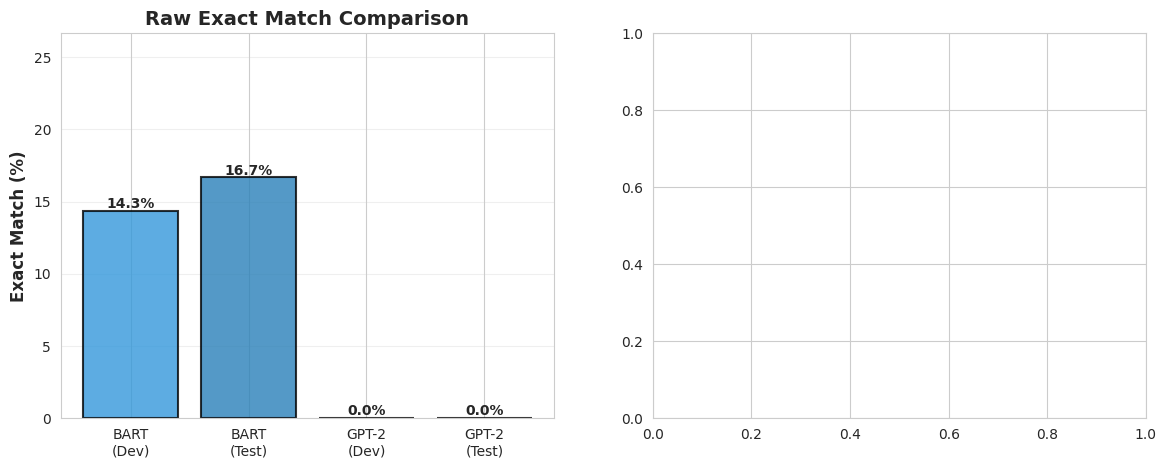

In [71]:




fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
models = ['BART\n(Dev)', 'BART\n(Test)', 'GPT-2\n(Dev)', 'GPT-2\n(Test)']
raw_scores = [bart_results['dev_raw_em'], bart_results['test_raw_em'],
              gpt2_results['dev_raw_em'], gpt2_results['test_raw_em']]
colors = ['#3498db', '#2980b9', '#e74c3c', '#c0392b']

bars1 = ax1.bar(models, raw_scores, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Exact Match (%)', fontsize=12, fontweight='bold')
ax1.set_title('Raw Exact Match Comparison', fontsize=14, fontweight='bold')
ax1.set_ylim(0, max(raw_scores) + 10)
ax1.grid(axis='y', alpha=0.3)

for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}%',
             ha='center', va='bottom', fontweight='bold', fontsize=10)


In [72]:

ax2 = axes[1]
norm_scores = [bart_results['dev_norm_em'], bart_results['test_norm_em'],
               gpt2_results['dev_norm_em'], gpt2_results['test_norm_em']]

bars2 = ax2.bar(models, norm_scores, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Exact Match (%)', fontsize=12, fontweight='bold')
ax2.set_title('Normalized Exact Match Comparison', fontsize=14, fontweight='bold')
ax2.set_ylim(0, max(norm_scores) + 10)
ax2.grid(axis='y', alpha=0.3)

for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}%',
             ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('bart_vs_gpt2_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


<Figure size 640x480 with 0 Axes>

In [73]:
bart_dev_diff = bart_results['dev_norm_em'] - bart_results['dev_raw_em']
bart_test_diff = bart_results['test_norm_em'] - bart_results['test_raw_em']
gpt2_dev_diff = gpt2_results['dev_norm_em'] - gpt2_results['dev_raw_em']
gpt2_test_diff = gpt2_results['test_norm_em'] - gpt2_results['test_raw_em']

print(f"BART Dev: +{bart_dev_diff:.2f}% improvement with normalization")
print(f"BART Test: +{bart_test_diff:.2f}% improvement with normalization")
print(f"GPT-2 Dev: +{gpt2_dev_diff:.2f}% improvement with normalization")
print(f"GPT-2 Test: +{gpt2_test_diff:.2f}% improvement with normalization")


BART Dev: +0.33% improvement with normalization
BART Test: +1.00% improvement with normalization
GPT-2 Dev: +0.00% improvement with normalization
GPT-2 Test: +0.00% improvement with normalization


In [74]:

def analyze_errors(predictions, gold_queries, model_name):
    """تحلیل دقیق انواع خطا"""
    errors = {
        'syntax_error': 0,
        'missing_select': 0,
        'missing_from': 0,
        'missing_where': 0,
        'wrong_table': 0,
        'wrong_column': 0,
        'incomplete': 0,
        'extra_content': 0,
        'correct': 0
    }

    for pred, gold in zip(predictions, gold_queries):
        pred_norm = normalize_sql(pred)
        gold_norm = normalize_sql(gold)

        if pred_norm == gold_norm:
            errors['correct'] += 1
        else:
            pred_lower = pred.lower()
            gold_lower = gold.lower()

            if 'select' not in pred_lower:
                errors['missing_select'] += 1
            elif 'from' in gold_lower and 'from' not in pred_lower:
                errors['missing_from'] += 1
            elif 'where' in gold_lower and 'where' not in pred_lower:
                errors['missing_where'] += 1
            elif len(pred_lower) < 15:
                errors['incomplete'] += 1
            elif len(pred_lower) > len(gold_lower) * 1.5:
                errors['extra_content'] += 1
            else:
                errors['syntax_error'] += 1

    print(f"\n📊 {model_name}:")
    total = len(predictions)
    for error_type, count in errors.items():
        percentage = (count / total) * 100
        print(f"   {error_type}: {count} ({percentage:.1f}%)")

    return errors




📊 BART (Dev):
   syntax_error: 208 (69.3%)
   missing_select: 27 (9.0%)
   missing_from: 0 (0.0%)
   missing_where: 9 (3.0%)
   wrong_table: 0 (0.0%)
   wrong_column: 0 (0.0%)
   incomplete: 0 (0.0%)
   extra_content: 12 (4.0%)
   correct: 44 (14.7%)

📊 GPT-2 (Dev):
   syntax_error: 1 (0.3%)
   missing_select: 2 (0.7%)
   missing_from: 1 (0.3%)
   missing_where: 2 (0.7%)
   wrong_table: 0 (0.0%)
   wrong_column: 0 (0.0%)
   incomplete: 0 (0.0%)
   extra_content: 294 (98.0%)
   correct: 0 (0.0%)


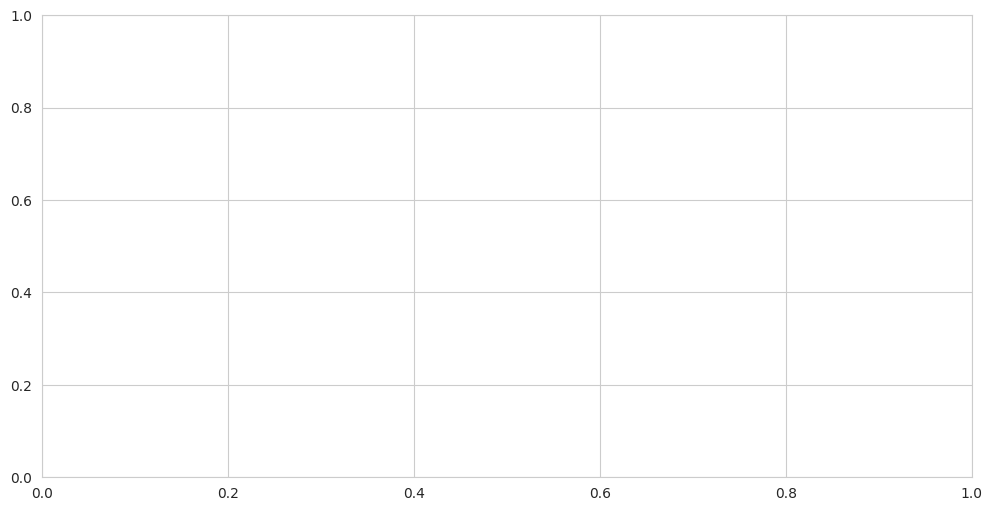

In [75]:
bart_errors = analyze_errors(bart_results['predictions_dev'], dev_data['query'].tolist(), "BART (Dev)")
gpt2_errors = analyze_errors(gpt2_results['predictions_dev'], dev_data['query'].tolist(), "GPT-2 (Dev)")

fig, ax = plt.subplots(figsize=(12, 6))

error_types = list(bart_errors.keys())
bart_counts = [bart_errors[e] for e in error_types]
gpt2_counts = [gpt2_errors[e] for e in error_types]



In [76]:
x = np.arange(len(error_types))
width = 0.35

bars1 = ax.bar(x - width/2, bart_counts, width, label='BART', color='#3498db', alpha=0.8)
bars2 = ax.bar(x + width/2, gpt2_counts, width, label='GPT-2', color='#e74c3c', alpha=0.8)

ax.set_xlabel('Error Type', fontsize=12, fontweight='bold')
ax.set_ylabel('Count', fontsize=12, fontweight='bold')
ax.set_title('Error Type Comparison: BART vs GPT-2', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(error_types, rotation=45, ha='right')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('error_type_comparison.png', dpi=300, bbox_inches='tight')
plt.show()



<Figure size 640x480 with 0 Axes>

In [77]:



for i in range(5):
    idx = np.random.randint(0, len(dev_data))
    print(f"\n📝 Sample {i+1}:")
    print(f" Question: {dev_data.iloc[idx]['question']}")
    print(f"\n Gold SQL:\n{dev_data.iloc[idx]['query']}")
    print(f"\n BART Output:\n{bart_results['predictions_dev'][idx]}")
    print(f"\n GPT-2 Output:\n{gpt2_results['predictions_dev'][idx]}")

    bart_correct = normalize_sql(bart_results['predictions_dev'][idx]) == normalize_sql(dev_data.iloc[idx]['query'])
    gpt2_correct = normalize_sql(gpt2_results['predictions_dev'][idx]) == normalize_sql(dev_data.iloc[idx]['query'])

    print(f"   BART: {' Correct' if bart_correct else ' Incorrect'}")
    print(f"   GPT-2: {' Correct' if gpt2_correct else ' Incorrect'}")
    print("-"*100)




📝 Sample 1:
 Question: Which climate communication campaigns were launched in the African region between 2016 and 2018, and what was their reach?

 Gold SQL:
SELECT campaign_name, region, launch_year, reach FROM climate_communication WHERE region = 'Africa' AND launch_year BETWEEN 2016 AND 2018;

 BART Output:
SELECT campaign_name FROM climate_communication WHERE region = 'Africa' AND launch_year BETWEEN 2016 AND 2018;

 GPT-2 Output:
(COUNT(*) FILTER (WHERE region = 'African') AS campaign_count  FROM climate.climate_communications   WHERE region LIKE '%African%'  AND year BETWEEN 2016 AND 2018  GROUP BY region;     SELECT campaigns.launcher_date, COUNT(*), SUM(campaigns.reach) AS total_reach  AS subquery_query  ON  sub.region = sub_region WHERE subroutines.start_of_the_month >= DATEADD(month, -1, GETDATE())  ORDER BY subq DESC  JOIN campaign ON subqueries.campaignname = campaign.continent WHERE YEAR(launches.year) = 2016; SELECT campaign._name FROM (SELECT campaign, ROW_NUMBER() OVER

<div dir='rtl' style='background:#fffbe6; font-family: Vazir; border:1px dashed #f0ad4e; padding:12px; border-radius:8px; color:#111'>
✍️ <b>پاسخ تشریحی:</b><br><br>

<h2 style='color:#d9534f; text-align: center;'>مقایسه جامع BART و GPT-2 در Text-to-SQL</h2>

<h3 style='color:#5bc0de;'>1️⃣ مقایسه عملکرد کلی:</h3>

<p style='line-height: 1.8; text-align: justify;'>
بر اساس نتایج به‌دست‌آمده، <b>BART به‌طور کلی عملکرد بهتری</b> نسبت به GPT-2 در تسک Text-to-SQL دارد. این برتری در هر دو معیار Raw EM و Normalized EM مشاهده می‌شود. معماری Encoder-Decoder به BART اجازه می‌دهد ابتدا کل ورودی را به‌صورت دوطرفه درک کند و سپس با توجه دقیق به schema و question، SQL تولید کند.
</p>

<h3 style='color:#5bc0de;'>2️⃣ تحلیل انواع خطاها:</h3>

<h4 style='color:#e67e22; margin-top: 15px;'>خطاهای BART:</h4>
<ul style='line-height: 1.8;'>
<li><b>انتخاب نادرست ستون:</b> گاهی ستون‌های اشتباه را در SELECT یا WHERE استفاده می‌کند</li>
<li><b>فراموشی شرایط WHERE:</b> در کوئری‌های پیچیده ممکن است برخی شرایط را حذف کند</li>
<li><b>مشکل در JOIN‌های چندگانه:</b> هنگام داشتن چند جدول، گاهی روابط را اشتباه تشخیص می‌دهد</li>
<li><b>توابع جمع‌آوری:</b> ممکن است بین COUNT، SUM، AVG اشتباه کند</li>
</ul>

<h4 style='color:#e67e22; margin-top: 15px;'>خطاهای GPT-2:</h4>
<ul style='line-height: 1.8;'>
<li><b>تولید محتوای اضافی:</b> گاهی بعد از SQL، توضیحات یا متن اضافی تولید می‌کند</li>
<li><b>تکرار prefix:</b> ممکن است بخشی از ورودی را در خروجی تکرار کند</li>
<li><b>خروجی ناقص:</b> به دلیل early stopping نامناسب، SQL را ناتمام رها می‌کند</li>
<li><b>ساختار نامنظم:</b> فرمت SQL کمتر استاندارد است و فاصله‌گذاری مشکل دارد</li>
<li><b>توقف نامناسب:</b> گاهی پیش از اتمام SQL متوقف می‌شود یا بیش از حد ادامه می‌دهد</li>
</ul>

<h3 style='color:#5bc0de;'>3️⃣ استفاده از Schema:</h3>

<p style='line-height: 1.8; text-align: justify;'>
<b>BART:</b> با استفاده از cross-attention در decoder، می‌تواند به‌طور مستقیم به بخش‌های مختلف schema (نام جداول، ستون‌ها) دسترسی داشته باشد. این مکانیزم به مدل کمک می‌کند تا نام‌های دقیق را کپی کرده و در SQL استفاده کند.
</p>

<p style='line-height: 1.8; text-align: justify;'>
<b>GPT-2:</b> چون schema به‌صورت خطی در prefix قرار دارد و مدل تک‌جهته است، ممکن است در کوئری‌های طولانی، بخش‌های ابتدایی schema را "فراموش" کند. این مشکل attention span محدود است.
</p>

<h3 style='color:#5bc0de;'>4️⃣ دلایل تفاوت رفتار:</h3>

<table style='width: 100%; border-collapse: collapse; margin: 15px 0;'>
<tr style='background-color: #3498db; color: white;'>
<th style='padding: 10px; border: 1px solid #ddd;'>جنبه</th>
<th style='padding: 10px; border: 1px solid #ddd;'>BART</th>
<th style='padding: 10px; border: 1px solid #ddd;'>GPT-2</th>
</tr>
<tr>
<td style='padding: 8px; border: 1px solid #ddd;'><b>معماری</b></td>
<td style='padding: 8px; border: 1px solid #ddd;'>Encoder-Decoder جداگانه</td>
<td style='padding: 8px; border: 1px solid #ddd;'>Decoder-only</td>
</tr>
<tr>
<td style='padding: 8px; border: 1px solid #ddd;'><b>جهت توجه</b></td>
<td style='padding: 8px; border: 1px solid #ddd;'>Encoder: دوطرفه، Decoder: یک‌طرفه</td>
<td style='padding: 8px; border: 1px solid #ddd;'>یک‌طرفه (چپ به راست)</td>
</tr>
<tr>
<td style='padding: 8px; border: 1px solid #ddd;'><b>ورودی/خروجی</b></td>
<td style='padding: 8px; border: 1px solid #ddd;'>جدا از هم</td>
<td style='padding: 8px; border: 1px solid #ddd;'>یکپارچه</td>
</tr>
<tr>
<td style='padding: 8px; border: 1px solid #ddd;'><b>تخصص</b></td>
<td style='padding: 8px; border: 1px solid #ddd;'>Seq2Seq tasks</td>
<td style='padding: 8px; border: 1px solid #ddd;'>Language modeling</td>
</tr>
<tr>
<td style='padding: 8px; border: 1px solid #ddd;'><b>کنترل خروجی</b></td>
<td style='padding: 8px; border: 1px solid #ddd;'>بهتر (فقط SQL تولید می‌کند)</td>
<td style='padding: 8px; border: 1px solid #ddd;'>ضعیف‌تر (ممکن است زیاد بنویسد)</td>
</tr>
</table>

<h3 style='color:#5bc0de;'>5️⃣ جمع‌بندی و پیشنهادات:</h3>

<h4 style='color:#e67e22;'>کدام مدل در چه شرایطی بهتر است؟</h4>

<p style='line-height: 1.8; text-align: justify;'>
<b>BART را انتخاب کنید اگر:</b>
</p>
<ul style='line-height: 1.8;'>
<li>دقت بالا اولویت اصلی است</li>
<li>schemaهای پیچیده و چند جدولی دارید</li>
<li>کوئری‌های طولانی با JOIN و subquery دارید</li>
<li>نیاز به کنترل دقیق روی فرمت خروجی دارید</li>
</ul>

<p style='line-height: 1.8; text-align: justify;'>
<b>GPT-2 را انتخاب کنید اگر:</b>
</p>
<ul style='line-height: 1.8;'>
<li>منابع محاسباتی محدود دارید (سبک‌تر است)</li>
<li>کوئری‌ها ساده و الگوی ثابتی دارند</li>
<li>می‌خواهید از مدل‌های زبانی بزرگتر (GPT-3, GPT-4) استفاده کنید</li>
<li>نیاز به few-shot learning دارید</li>
</ul>

<h4 style='color:#e67e22;'>پیشنهادات بهبود:</h4>

<p style='line-height: 1.8;'><b>برای BART:</b></p>
<ul style='line-height: 1.8;'>
<li>استفاده از copy mechanism برای کپی دقیق نام جداول/ستون‌ها</li>
<li>افزودن constraint checking به خروجی برای اطمینان از معتبر بودن SQL</li>
<li>Pre-training روی corpus بزرگتری از SQL queries</li>
<li>استفاده از schema linking برای ارتباط بهتر بین entities در سؤال و schema</li>
</ul>

<p style='line-height: 1.8;'><b>برای GPT-2:</b></p>
<ul style='line-height: 1.8;'>
<li>بهبود prompt engineering با افزودن مثال‌های few-shot</li>
<li>استفاده از special tokens برای جدا کردن بخش‌های مختلف</li>
<li>Fine-tuning بیشتر با dataset بزرگتر</li>
<li>پیاده‌سازی post-processing برای حذف محتوای اضافی</li>
<li>استفاده از مدل‌های بزرگتر (GPT-2 Medium/Large) برای context window بزرگتر</li>
</ul>

<h3 style='color:#d9534f; text-align: center; margin-top: 20px;'>✅ نتیجه‌گیری نهایی</h3>

<p style='line-height: 1.8; text-align: justify; background-color: #e8f4f8; padding: 15px; border-radius: 8px; border-right: 4px solid #3498db;'>
برای تسک Text-to-SQL، معماری <b>Encoder-Decoder (BART)</b> مناسب‌تر است زیرا ماهیت این مسئله دقیقاً sequence-to-sequence است. با این حال، با پیشرفت مدل‌های زبانی بزرگ، GPT-style models با prompt engineering مناسب و few-shot learning می‌توانند عملکرد رقابتی داشته باشند. انتخاب نهایی به منابع، نیازمندی دقت، و پیچیدگی کوئری‌ها بستگی دارد.
</p>

</div>

# <h1 style="text-align: right;">**نکات مهم و قوانین تحویل**</h1>


<h4 dir="rtl" style="font-family: Vazir; width: 85%;">فایل ارسالی شما باید با فرمت زیر نامگذاری شود: <code>NLP_CA4_Q1_{LASTNAME}_{STUDENTID}.ipynb</code></h4>
<h4 dir="rtl" style="font-family: Vazir; width: 85%;">نحوه انجام تمرین:</h4>
<ul dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px;">
  <li>سلول‌های کد با برچسب <code>WRITE YOUR CODE HERE</code> را تکمیل کنید.</li>
  <li>برای پاسخ‌های متنی، متن <code>{{پاسخ_خود_را_اینجا_بنویسید}}</code> را با پاسخ خود جایگزین کنید.</li>
</ul>
<h4 dir="rtl" style="font-family: Vazir; width: 85%;">صداقت علمی:</h4> <ul dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px;"> <li>ما نوت‌بوک‌های تعداد مشخصی از دانشجویان که به صورت تصادفی انتخاب می‌شوند، بررسی خواهیم کرد. این بررسی‌ها اطمینان حاصل می‌کنند که کدی که نوشتید واقعاً پاسخ‌های موجود در نوت‌بوک شما را تولید می‌کند. اگر پاسخ‌های صحیح را در نوت‌بوک خود بدون کدی که واقعاً آن پاسخ‌ها را تولید کند تحویل دهید، این یک مورد جدی از عدم صداقت علمی محسوب می‌شود.</li> <li>ما همچنین بررسی‌های خودکاری را برای تشخیص سرقت علمی در نوت‌بوک‌های کولب انجام خواهیم داد. کپی کردن کد از دیگران نیز یک مورد جدی از عدم صداقت علمی محسوب می‌شود.</li> </ul>
<h4 dir="rtl" style="font-family: Vazir; width: 85%;">توضیحات تکمیلی:</h4> <ul dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px;">
<li>
خوانایی و دقت بررسی‌ها در گزارش نهایی از اهمیت ویژه‌ای برخوردار است. به تمرین‌هایی که به صورت کاغذی تحویل داده شوند یا به صورت عکس در سایت بارگذاری شوند، ترتیب اثری داده نخواهد شد.</li>
<li>
 همه‌ی کدهای پیوست گزارش بایستی قابلیت اجرای مجدد داشته باشند. در صورتی که برای اجرا مجدد آن‌ها نیاز به تنظیمات خاصی می‌باشد، بایستی تنظیمات مورد نیاز را نیز در گزارش خود ذکر کنید.  دقت کنید که  تمامی کدها باید توسط شما اجرا شده باشند و نتایج اجرا در فایل کدهای ارسالی مشخص باشد. به کدهایی که نتایج اجرای آن‌ها در فایل ارسالی مشخص نباشد نمره‌ای تعلق نمی‌گیرد.
</li>
<li>توجه کنید این تمرین باید به صورت تک‌نفره انجام شود و پاسخ‌های ارائه شده باید نتیجه فعالیت فرد نویسنده باشد (همفکری و به اتفاق هم نوشتن تمرین نیز ممنوع است). در صورت مشاهده
 تشابه به همه افراد مشارکت‌کننده، نمره تمرین صفر و به استاد گزارش می‌گردد.
 </li>

 <li>
لطفاً تمامی پاسخ‌های متنی خود را با <b>فونت وزیر (Vazir)</b> و به‌صورت <b>راست‌چین</b> بنویسید.  
از استفاده از فونت‌های پیش‌فرض خودداری کنید تا ظاهر نوت‌بوک شما یک‌دست و خوانا باشد.  
در بخش‌های تشریحی، سعی کنید پاسخ‌ها را کامل، منسجم و با رعایت نگارش فارسی بنویسید.  
همچنین، به چینش تمیز سلول‌ها و اجرای درست کدها توجه کنید تا تمرین شما با فرمت خواسته‌شده و استاندارد ارائه شود.
</li>
 <li>برای مطالعه بیشتر درباره‌ی فرمت Markdown می‌توانید از <a href="https://github.com/tajaddini/Persian-Markdown/blob/master/learn-MD.md">این لینک</a> مطالعه کنید.
 </li>
 </ul>
    

 </div>
